In [1]:
%load_ext autoreload
%autoreload 2

import json
from os.path import join
import copy
import random
import numpy as np
import pandas as pd 
from scipy import stats
from tqdm import tqdm
import math

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.ndimage import zoom

import torch
import torch.nn.functional as F

from common.config import JsonConfig
from ffm_iql.builder import build 
from ffm_iql.evaluation import evaluate, sample_scanpaths


from PIL import ImageFont, Image, ImageDraw
font = ImageFont.truetype("Gidole-Regular.ttf", size=32)
import cv2

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns


from visualization_utils import *
import datetime as dt
today = dt.date.today()          # e.g. datetime.date(2025, 7, 15)
today_mmdd = today.strftime("%m%d")  # '0715'

device = torch.device('cuda:1')
# device = torch.device('cpu')
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [2]:
CATEGORIES18 = ['bottle',
'bowl',
'car',
'chair',
'clock',
'cup',
'fork',
'keyboard',
'knife',
'laptop',
'microwave',
'mouse',
'oven',
'potted plant',
'sink',
'stop sign',
'toilet',
'tv']


# load model and dataset

In [3]:
# TAP='TP' 
TAP='TPtoTA'

#dataset_root = '/home/young/hdd1/coco-search18/'
dataset_root = '/data/datasets/coco-search18-IRL/'
hparams = JsonConfig('./configs/coco_search18_eDCB_IQL_TP_LIOR.json')
# hparams = JsonConfig('./configs/coco_search18_eDCB_IQL_TA_LIOR.json')


# hparams.Train['force_IOR'] = False

# save_visualization = False
# log_dir = './results/explore_it'
# if not os.path.exists(log_dir):
#     os.makedirs(log_dir)
# print("Log dir:", log_dir)
# config_dir = os.path.dirname(args.hparams)

hparams_tp = JsonConfig('./configs/coco_search18_TP.json')
hparams_ta = JsonConfig('./configs/coco_search18_TA.json')
hparams_fv = JsonConfig('./configs/coco_search18_FV.json')

if TAP=='TPtoTA':
    # change hparam to TA setup
    hparams_ta_training = JsonConfig('./configs/coco_search18_eDCB_IQL_TA_LIOR.json')
    maxtrajcopy = hparams.Data.max_traj_length
    hparams.Data = hparams_ta_training.Data
    hparams.Data.max_traj_length =maxtrajcopy
    hparams_ta.Data.max_traj_length =maxtrajcopy
    

# build model
agent, train_gaze_loader, train_img_loader, valid_img_loader,\
    valid_img_loader_ta, valid_img_loader_fv, env_train, env_valid, global_step, bbox_annos,\
    human_cdf, fix_clusters, prior_maps_tp, prior_maps_ta, prior_maps_fv,\
    sss_strings, valid_gaze_loader_tp, valid_gaze_loader_ta, valid_gaze_loader_fv,\
    sps_test_tp, sps_test_ta, sps_test_fv, sps_train_tp, sps_train_ta, sps_train_fv = build(
        hparams, dataset_root, device, load_coco_annos=False, evaluation_on_training=True)



if TAP == 'TPtoTA':
    TAP = 'TA'
    
# using DCB dataset: COCO-Search18 TAP: TP
# average train scanpath length : 3.637 (+/-1.850)
# num of train trajs = 18961
# average valid scanpath length : 3.620 (+/-1.782)
# num of valid trajs = 5424
# target fixation prob (valid).: [0.00847614 0.46334244 0.80982789 0.93608998 0.97351685 0.9874683 ]
# num of training and eval fixations = 35856, 9974
# num of training and eval images = 2163, 612 (TP), 612 (TA), 0(FV)
# num of training batches = 1120
# loaded weights from ./pretrained/ckp_temporal_TP.pt.


# using DCB dataset: COCO-Search18 TAP: TA
# average train scanpath length : 5.836 (+/-4.035)
# num of train trajs = 21627
# average valid scanpath length : 5.852 (+/-4.208)
# num of valid trajs = 6120
# target fixation prob (valid).: [0.00847614 0.46334244 0.80982789 0.93608998 0.97351685 0.9874683
#  0.99304122]
# num of training and eval fixations = 104597, 29694
# num of training and eval images = 2163, 612 (TP), 612 (TA), 0(FV)
# num of training batches = 3268
# loaded weights from ./pretrained/ckp_temporal_TP.pt.

# load baselines
DETECTOR_PRED_PATH = f"./baselines/Foveated Detector/pred_{TAP}_detection_hilow_aug_noIOR.npy"
HAT_PRED_PATH = f"./baselines/HAT/pred_{TAP}_HAT_maxlen.npy"
print('baseline loaded')

using DCB dataset: COCO-Search18 TAP: TA
average train scanpath length : 5.836 (+/-4.035)
num of train trajs = 21627
average valid scanpath length : 5.852 (+/-4.208)
num of valid trajs = 6120
target fixation prob (valid).: [0.00847614 0.46334244 0.80982789 0.93608998 0.97351685 0.9874683 ]
num of training and eval fixations = 104597, 29694
num of training and eval images = 2163, 612 (TP), 612 (TA), 0(FV)
num of training batches = 3269
loaded weights from ./pretrained/ckp_temporal_TP.pt.
baseline loaded


# Generate model scanpaths and reward maps 

In [4]:
# code modified from evalaute in evaluation.py
env = env_valid
model = agent

    
if hparams.Data.TAP == 'TP':
    dataloader = valid_img_loader # train_img_loader for using training image
    pa= hparams_tp.Data
#     pa['enforce_IOR'] = False
#     print(pa)
if hparams.Data.TAP == 'TA':
    dataloader =  valid_img_loader_ta
    pa= hparams_ta.Data
#     pa['enforce_IOR'] = False

model.eval()


scanpaths, visualizations = sample_scanpaths(env, model, dataloader, pa,
                                             sample_action=False, 
                                             sample_scheme='Greedy', # this is not necessary
                                             sample_stop=False,
                                             save_visualization=True)

Generating scanapths...


  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:42<00:00,  2.11s/it]


# Test model performance

In [ ]:
# # code modified from evalaute in evaluation.py
# # insert log_dir for saving visualizations

# env = env_valid
# model = agent

# def run_evaluation():
#     rst_tp, rst_ta, rst_fv = None, None, None
#     if hparams.Data.TAP in ['TP', 'TAP']:
#         rst_tp = evaluate(
#             env_valid,
#             agent,
#             valid_img_loader,
#             valid_gaze_loader_tp,
#             hparams_tp.Data,
#             bbox_annos,
#             human_cdf,
#             fix_clusters,
#             prior_maps_tp,
#             sss_strings,
#             dataset_root,
#             sps_test_tp,
#             sample_action=False,
#             sample_scheme='Greedy',
#             log_dir=None,
#             save_visualization=False,
#         )
#         print("TP:", rst_tp)
#     if hparams.Data.TAP in ['TA', 'TAP']:
#         rst_ta = evaluate(
#             env_valid,
#             agent,
#             valid_img_loader_ta,
#             valid_gaze_loader_ta,
#             hparams_ta.Data,
#             bbox_annos,
#             human_cdf,
#             fix_clusters,
#             prior_maps_ta,
#             sss_strings,
#             dataset_root,
#             sps_test_ta,
#             sample_action=False,
#             sample_scheme='Greedy',
#             log_dir=None,
#             save_visualization=False,
#         )
#         print("TA", rst_ta)
#     if hparams.Data.TAP in ['FV', 'ALL']:
#         rst_fv = evaluate(
#             env_valid,
#             agent,
#             valid_img_loader_fv,
#             valid_gaze_loader_fv,
#             hparams_fv.Data,
#             bbox_annos,
#             human_cdf,
#             fix_clusters,
#             prior_maps_fv,
#             sss_strings,
#             dataset_root,
#             sps_test_fv,
#             sample_action=False,
#             sample_scheme='Greedy',
#             log_dir=None,
#             save_visualization=False,
#         )
#         print("FV", rst_fv)
#     return rst_tp, rst_ta, rst_fv

# metrics = run_evaluation()
# # print(metrics)]

# # generate categoriwise performance
# metric_columns = ['TFP', 'SS', 'SemSS', 'cIG', 'cNSS', 'cAUC', 'SPR']
# # metric_columns = ['SemSS', 'SS', 'cIG', 'cNSS', 'cAUC']

# dfs = []
# for i, cat in enumerate(CATEGORIES18:
#     df = pd.read_csv(f'results/DCBablation_SemSSupdated/metric_{cat}.csv')
#     dfs.append(df.iloc[0].to_frame().transpose().copy())
    
# alldf = pd.concat(dfs)[metric_columns]
# alldf['label'] = CATEGORIES18
# alldf.to_csv('results/TP_all_categories_SemSSupdated.csv', index=False)
# alldf

# Load human scanpaths

In [5]:
def load_human_scanpaths(split, TAP, dataset_root='/data/datasets/coco-search18-IRL/'):
    print(f'Generating {split} dataset for: {TAP}')
    fixation_path = dataset_root + 'coco_search_fixations_512x320_on_target_allvalid.json'
    with open(fixation_path) as json_file:
        human_all = json.load(json_file)

    if TAP == 'TP':
        human = list(filter(lambda x: x['condition'] == 'present' and x['split'] == split, human_all))
    else:
        human = list(filter(lambda x: x['condition'] == 'absent' and x['split'] == split, human_all))

    for sp in human:
        sp['X'][0], sp['Y'][0] = 256, 160  # center correction

    print(f'Total scanpaths for {split}:', len(human))
    return human


human_scanpaths = load_human_scanpaths('test', TAP, dataset_root)
taskimgpair = np.unique([sp['task'] + "_" + sp['name'] for sp in human_scanpaths])
print('unique task-img pair', len(taskimgpair))

# print('unique task-img pair', len(task_img_pairs))
# np.save(f'/data/datasets/coco-search18-IRL/nfixtrain_{TAP}_task_img_pair.npy', task_img_pairs)

######
# image-wise stats
#####
statperimage = pd.DataFrame()

tasks, imgnames, nfixs, nfixs_sd, accs, accs_sd= [], [], [], [], [], []
for pair in taskimgpair:
    task= pair.split('_')[0]
    imgname = pair.split('_')[1]
    tasks.append(task)
    imgnames.append(imgname)
    
    img_scanpaths = list(filter(lambda x: x['task'] +"_"+ x['name'] == pair, human_scanpaths))

    if TAP=='TP':
        valid_sp = list(filter(lambda x: x['correct'] and x['fixOnTarget'], img_scanpaths))

        acc = len(valid_sp)/(len(img_scanpaths))
        accs.append(acc)

        nfix = [sp['length'] for sp in valid_sp]
        nfixs.append(np.mean(nfix) if nfix else np.nan)
        # nfixs_sd.append(np.std(nfix))
    
    elif TAP=='TPtoTA' or TAP=='TA':
        accs.append(np.nan)
        nfix = [sp['length'] for sp in img_scanpaths]
        nfixs.append(np.mean(nfix) if nfix else np.nan)
        # nfixs_sd.append(np.std(nfix))

statperimage['category']= tasks
statperimage['imgname']= imgnames
statperimage['nfix']= nfixs
# statperimage['nfix_sd']= nfixs_sd
statperimage['acc']= accs
gazestat_perimage = statperimage

######
# statistics per category
#####
# nfix is num of fixations made til button press
gazestat=pd.DataFrame()
nfixs, fixs_sd, accs = [], [], []
for category in CATEGORIES18:
    if TAP=='TP':
        valid_task_sp = list(filter(lambda x: x['task'] == category and x['correct'] and x['fixOnTarget'], human_scanpaths))
        invalid_task_sp = list(filter(lambda x: x['task'] == category and not (x['correct'] and x['fixOnTarget']), human_scanpaths))

        acc = len(valid_task_sp)/(len(valid_task_sp)+len(invalid_task_sp))
        accs.append(acc)
    
        nfix = [sp['length'] for sp in valid_task_sp]
        nfixs.append(np.mean(nfix) if nfix else np.nan)
        nfixs_sd.append(np.std(nfix) if nfix else np.nan)
    elif TAP=='TPtoTA' or TAP=='TA':
        valid_task_sp = list(filter(lambda x: x['task'] == category and x['correct'], human_scanpaths))
        
        accs.append(np.nan)
        
        nfix = [sp['length'] for sp in valid_task_sp]
        nfixs.append(np.mean(nfix) if nfix else np.nan)
        nfixs_sd.append(np.std(nfix) if nfix else np.nan)
    
gazestat['category'] = CATEGORIES18
gazestat['acc'] = accs
gazestat['nfix'] = nfixs
gazestat['nfix_sd'] = nfixs_sd
display(gazestat)


Generating test dataset for: TA
Total scanpaths for test: 6120
unique task-img pair 612


,category,acc,nfix,nfix_sd
0,bottle,NaN,5.530000,4.174019
1,bowl,NaN,6.983871,5.016881
2,car,NaN,6.386243,4.090772
3,chair,NaN,5.623853,3.499556
4,clock,NaN,6.027273,4.383770
5,cup,NaN,6.533181,5.496987
6,fork,NaN,6.832230,5.928799
7,keyboard,NaN,5.252778,3.243796
8,knife,NaN,5.812500,4.162789
9,laptop,NaN,6.728889,3.984672


# reward map visualizations
- temporal evolution of groundtruth needed...

In [17]:
category = 'microwave'
# category = 'toilet'
# category = 'potted plant'
# category = 'stop sign'
# category = 'cup'
# category = 'tv'

# def filter_by_category(x, catname):
#     return x[0] == catname
# vis = list(filter(lambda x: filter_by_category(x, category), visualizations))

# filter visualizations and scanpaths by category
vis_category = []
scanpath_category = []
for i, vis in enumerate(visualizations):
    if vis[0] == category:
        vis_category.append(vis)
        scanpath_category.append(scanpaths[i])
print(f'# of visualization data for {category}: ', len(vis_category))


# sample N easy and hard images
N_SAMPLE = 10
sorteddf = statperimage[statperimage.category==category].sort_values(by='nfix')
easy_images = sorteddf['imgname'].tolist()[:N_SAMPLE]
easy_nfixs = sorteddf['nfix'].tolist()[:N_SAMPLE]
hard_images = sorteddf['imgname'].tolist()[-abs(N_SAMPLE):]
hard_nfixs = sorteddf['nfix'].tolist()[-abs(N_SAMPLE):]
print(f'{N_SAMPLE} easy and hard images sampled')



# of visualization data for microwave:  31
10 easy and hard images sampled


Loaded baseline 'detector' from ./baselines/Foveated Detector/pred_TA_detection_hilow_aug_noIOR.npy with 612 items
Loaded baseline 'hat' from ./baselines/HAT/pred_TA_HAT_maxlen.npy with 612 items
Rendering 000000248111.jpg


Saved to ./results/savefig/TA_attention_map_microwave_000000248111.jpg.png


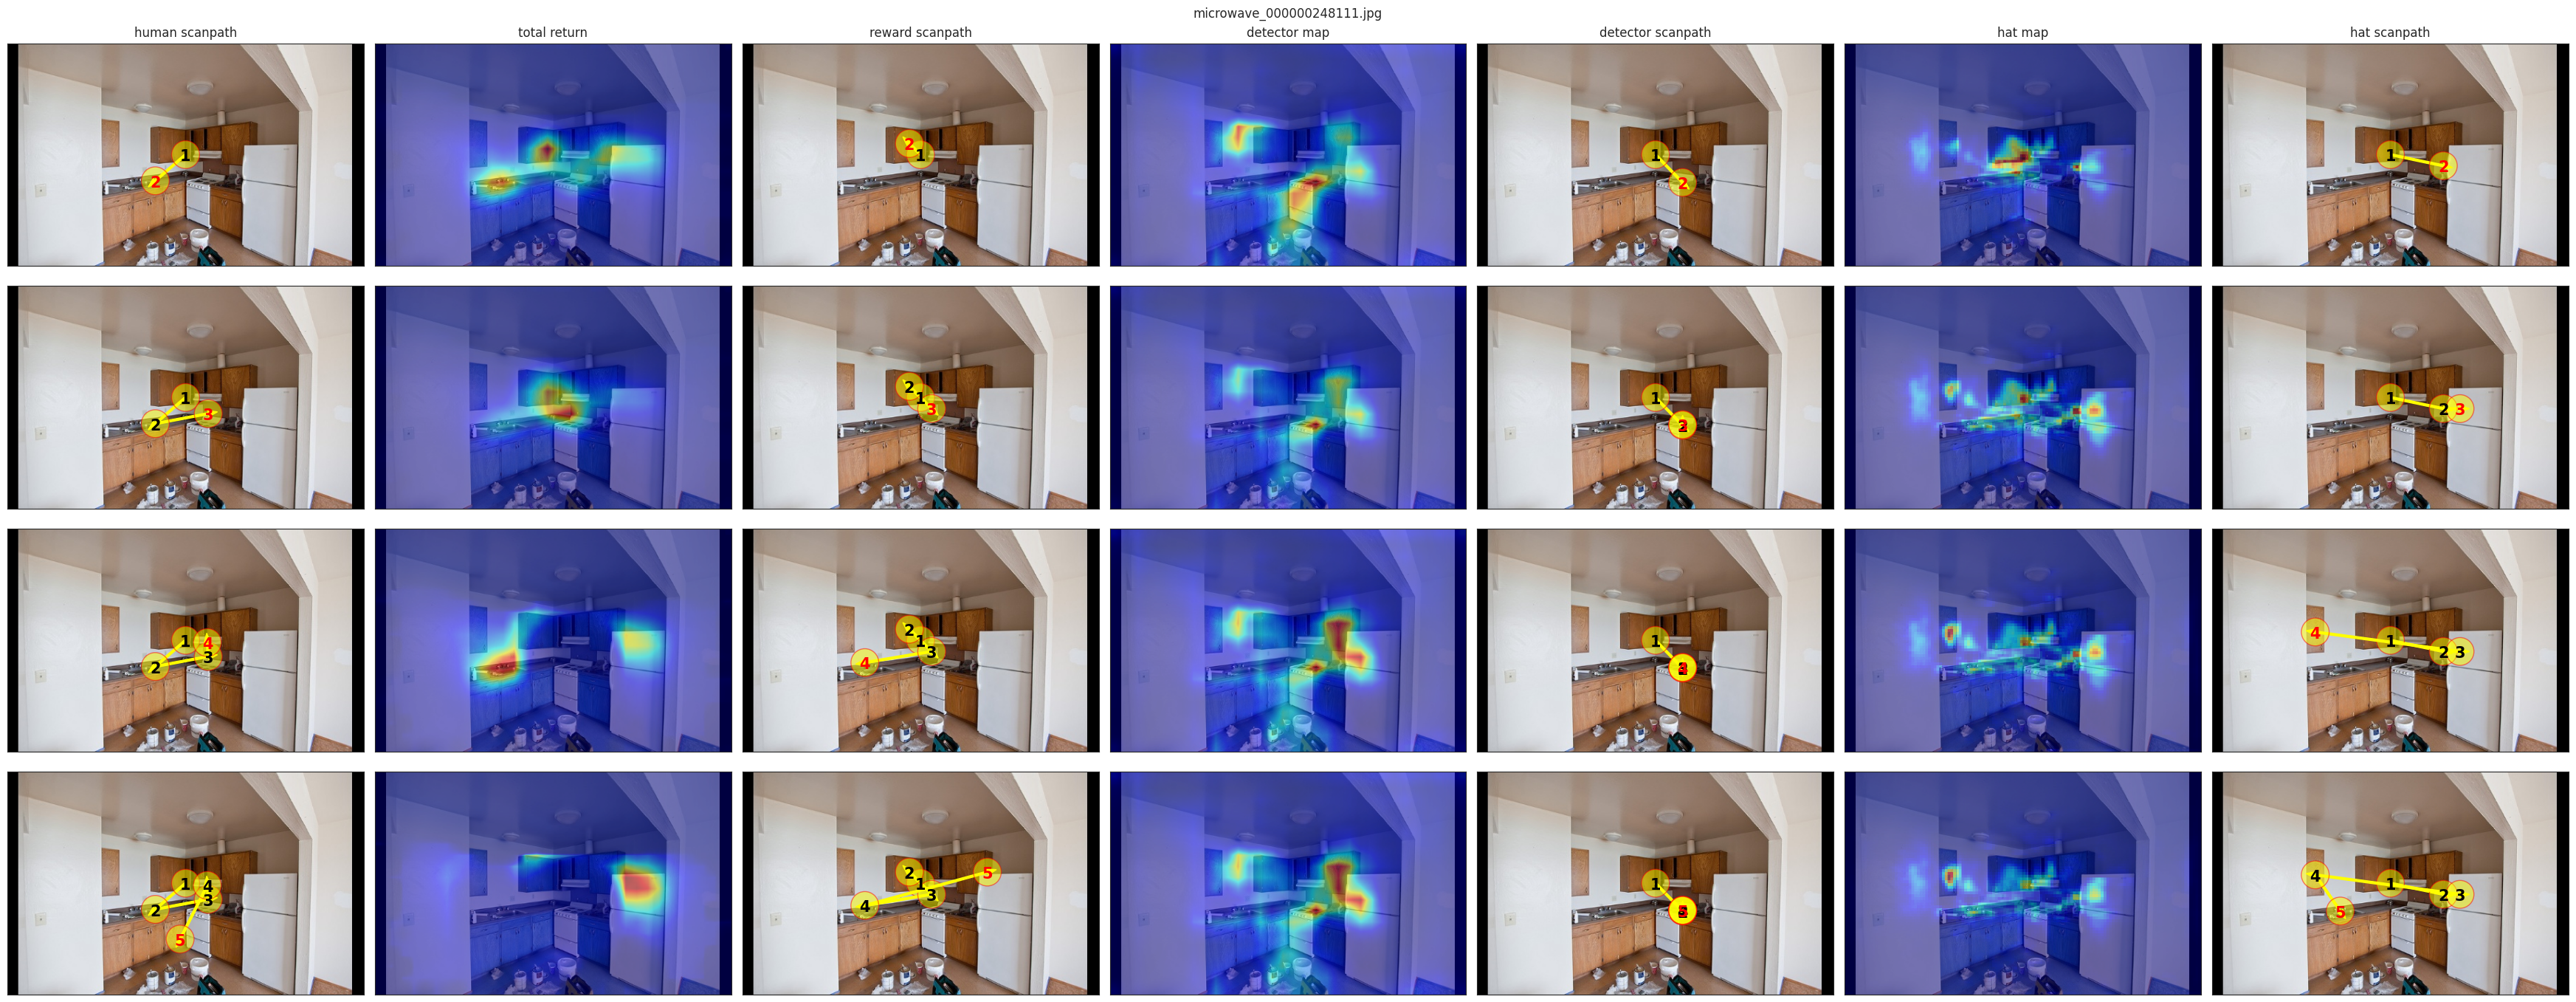

In [22]:
# visualize attention maps and scanpaths
## TODO: for TA condition you still get 6 for visualizations not entire
# 48939 training image is used for figure
# 000000253489.jpg for bottle change

# imglist_to_save = None
# # imglist_to_save=['000000253489.jpg'] # bottle search, explore-exploit change
# # imglist_to_save = ['000000325992.jpg'] # bottle
# # imglist_to_save =['000000360849.jpg'] # toilet search, easy case for entropy # 3 steps on average
# # imglist_to_save = ['000000124707.jpg'] # microwave search, hard case for entropy # 10 steps on average
# # imglist_to_save = ['000000317565.jpg', '000000345536.jpg', '000000415949.jpg'] # potted plant search TP (difficult case, for IOR illusrations)
# # imglist_to_save = ['000000317565.jpg'] # potted plant search TP (difficult case, for IOR illusrations)
# # imglist_to_save = ['000000096183.jpg' ] # microwave

# imglist_to_visualize = hard_images
# # imglist_to_visualize = imglist_to_save
# # imglist_to_visualize = 'all'
# imglist_to_visualize = ['000000296388.jpg']

# repscanpath = selected_human_scanpaths[2] # subj 5 >0 for microwave; subj 2>8 for potted plant

cfg = VizConfig(
    maps_to_visualize=['human scanpath', 'total return', 'reward scanpath', 'baseline attention map', 'baseline scanpath'], #  'action prob', 'immediate reward', 'expected future reward',  'reward scanpath', 'human_scanpath', 'baseline_scanpath'
    # imglist_to_visualize = ['000000360849.jpg'], # toilet search, easy case 
    # imglist_to_visualize = ['000000124707.jpg'], # microwave search, hard case
    # imglist_to_save= ['000000360849.jpg'],
    # imglist_to_save = ['000000124707.jpg'], 
    # imglist_to_visualize= ['000000233033.jpg'], # toilet search,  5.2, hard case among others, but target is easy
    # imglist_to_save= ['000000233033.jpg'],
    # imglist_to_visualize = ['000000291784.jpg'], # potted plant search, hard case  , 8.5
    # imglist_to_save = ['000000291784.jpg'],
    imglist_to_visualize = ['000000248111.jpg'], # microwave search
    imglist_to_save = ['000000248111.jpg'],   
    # imglist_to_visualize= easy_images,
    # imglist_to_save= [],
    tap=TAP,  # 'TP' or 'TPtoTA'
    save_path=f"./results/savefig/{TAP}_attention_map_",  # where to save the figures
    plot_entropy=False,
    draw_nstep=5, # default is None, which means all model steps are drawn
    baselines=[
        BaselineSpec(
            name="detector",
            pred_path= DETECTOR_PRED_PATH,
        ),
        BaselineSpec(
            name="hat",
            pred_path= HAT_PRED_PATH,
        )
    ],
)

visualize_rewardmaps(
    vis_category=vis_category,
    scanpath_category=scanpath_category,
    human_scanpaths=human_scanpaths,
    dataset_root=dataset_root,
    hparams=hparams,
    cfg=cfg,
)


# reward depletion
- at reward t: get 24 radius region of fixated; st = compute sum of values
- at reward t+1: get 24 radius region of previously fixated (same region); st+1 = compute sum of values
- (st - st+1) --> current - future reward. if positive :depleted, if zero or negative: not depleted

baseline "detector" loaded from ./baselines/Foveated Detector/pred_TA_detection_hilow_aug_noIOR.npy
baseline "hat" loaded from ./baselines/HAT/pred_TA_HAT_maxlen.npy


Processing categories: 100%|██████████| 18/18 [00:04<00:00,  3.86it/s]


[saved] ./results/savefig/TA_reward_depletion_overall_multi_entirescene.png


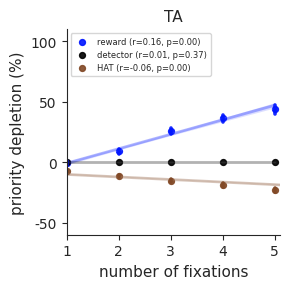

In [14]:
# ────────────────────────────────────────────────────────────────
# Multi-baseline reward depletion analysis (supports "target" + "hat")
# ────────────────────────────────────────────────────────────────
# Assumes the following exist in your workspace:
# - CATEGORIES18, visualizations, scanpaths
# - compute_reward(map, mask), foveal2mask(x, y, r, h, w)
# - format_p(p)   # pretty p-value formatter
# Uses: scipy.stats as stats, pandas as pd, numpy as np, tqdm

# === CONFIG ===
BASELINES = [
    # name, path pattern
    ("detector", DETECTOR_PRED_PATH),
    ("hat",    HAT_PRED_PATH),         # <-- adjust path if different
]

USE_DELTA = False
CURR_FIX_ONLY = False # if false, we are computing entire scene, for TA analsysis
RADIUS = 24

if CURR_FIX_ONLY:
    depletion_area = 'fixonly'
    ylabel = 'inhibition rate (%)'
else:
    depletion_area = 'entirescene'
    ylabel = 'priority depletion (%)'

SAVE_PATH = f'./results/savefig/{TAP}_reward_depletion_overall_multi_{depletion_area}.png'



# === LOAD BASELINES (optional if files missing) ===
baseline_preds = {}
for name, path in BASELINES:
    try:
        baseline_preds[name] = np.load(path, allow_pickle=True)
        print(f'baseline "{name}" loaded from {path}')
    except Exception as e:
        print(f'[WARN] Could not load baseline "{name}" from {path}: {e}')


# ───────────────────────────────────────────────────────
# Helper: compute rows for one model sequence (maps + fixations)
# ───────────────────────────────────────────────────────

def _minmax_norm(arr):
    arr = arr.astype(np.float32)
    a_min = np.nanmin(arr)
    a_max = np.nanmax(arr)
    rng = a_max - a_min
    if rng <= 1e-12:
        return np.zeros_like(arr, dtype=np.float32)
    return (arr - a_min) / rng

def _softmax_norm(arr, tau=1.0):
    # Produces a probability map that sums to 1 (over the whole image)
    # Lower tau -> sharper distribution; tau must be >0
    arr = arr.astype(np.float32)
    tau = float(tau) if tau is not None else 1.0
    if tau <= 0:
        tau = 1.0
    a = arr / tau
    a = a - np.nanmax(a)  # stabilize
    expa = np.exp(a)
    s = expa.sum()
    if s <= 1e-12:
        # fallback: uniform map if everything underflowed
        h, w = arr.shape
        return np.full((h, w), 1.0 / (h * w), dtype=np.float32)
    return expa / s

def compute_rows_one_model(model_name,
                           maps_seq,           # list/array of 2D maps for this model
                           fix_x_seq=None,     # list of X fixations for this model (optional)
                           fix_y_seq=None,     # list of Y fixations for this model (optional)
                           map_index_offset=0, # 0 for ours, 1 for baseline to mimic attn_map[step+1]
                           curr_fix_only=False,
                           radius=24,
                           h=None, w=None,
                           category=None, image_name=None,
                           use_delta=False,
                           norm='none',        # 'none' | 'minmax' | 'softmax'
                           softmax_temp=1.0):
    out = {'model': [], 'category': [], 'imgname': [], 'step': [], 'backN': [], 'IOR': [], 'curr_reward':[], 'next_reward':[]}

    n_eff = len(maps_seq) - map_index_offset
    if n_eff <= 1:
        return out  # nothing to compute

    # choose normalizer
    if norm == 'minmax':
        _norm_fn = _minmax_norm
    elif norm == 'softmax':
        _norm_fn = lambda a: _softmax_norm(a, tau=softmax_temp)
    else:
        _norm_fn = lambda a: a  # no-op

    for step in range(n_eff - 1):
        i_curr = step + map_index_offset

        # Build fixation mask at t = step+1 (to mirror your original convention)
        if curr_fix_only and (fix_x_seq is not None) and (fix_y_seq is not None):
            if step + 1 >= len(fix_x_seq) or step + 1 >= len(fix_y_seq):
                continue  # no fixation for this step; skip
            fx, fy = fix_x_seq[step + 1], fix_y_seq[step + 1]
            fix_mask = foveal2mask(fx, fy, radius, h, w)
        else:
            fix_mask = np.ones((h, w), dtype=np.uint8)

        # Normalize current map
        curr_map = _norm_fn(maps_seq[i_curr])
        curr_reward = compute_reward(curr_map, fix_mask)


        for next_step in range(step + 1, n_eff):
            i_next = next_step + map_index_offset

            # Normalize next map
            next_map = _norm_fn(maps_seq[i_next])
            next_reward = compute_reward(next_map, fix_mask)

            if use_delta:
                # delta computed on normalized maps
                delta_map = np.clip(curr_map - next_map, 0, None)
                denom = (curr_map[fix_mask].sum() + 1e-5)
                # IOR_val = 1 - (delta_map[fix_mask].sum() / denom)
                IOR_val = (delta_map[fix_mask].sum() / denom)
            else:
                # depletion ratio using normalized rewards
                # IOR_val = 1 - np.clip((curr_reward - next_reward) / (curr_reward + 1e-5), 0, 1)
                IOR_val = (curr_reward - next_reward) / (curr_reward + 1e-5)

            out['model'].append(model_name)
            out['category'].append(category)
            out['imgname'].append(image_name)
            out['step'].append(step + 1)           # 1-based
            out['backN'].append(next_step - step)  # distance
            out['IOR'].append(IOR_val)
            out['curr_reward'].append(curr_reward)
            out['next_reward'].append(next_reward)

    return out
# ───────────────────────────────────────────────────────
# MAIN LOOP — independent per model lengths
# ───────────────────────────────────────────────────────
rows = { 'model': [], 'category': [], 'imgname': [], 'step': [], 'backN': [], 'IOR': [] , 'curr_reward':[], 'next_reward':[]}

for category in tqdm(CATEGORIES18, desc="Processing categories"):
    vis_category = [vis for vis in visualizations if vis[0] == category]
    scanpath_category = [scanpaths[i] for i, vis in enumerate(visualizations) if vis[0] == category]
    if not vis_category:
        continue

    for vis, sp in zip(vis_category, scanpath_category):

        image_name, maps_ours = vis[1], vis[2] # total return
        h, w = maps_ours[0].shape

        if len(maps_ours) <= 1:
            pass
        else:
            ours_dict = compute_rows_one_model(
                model_name='ours',
                maps_seq=maps_ours,
                fix_x_seq=sp.get('X') if CURR_FIX_ONLY else None,
                fix_y_seq=sp.get('Y') if CURR_FIX_ONLY else None,
                map_index_offset=0,
                curr_fix_only=CURR_FIX_ONLY,
                radius=RADIUS,
                h=h, w=w,
                category=category, image_name=image_name,
                use_delta=USE_DELTA
            )
            for k in rows: rows[k].extend(ours_dict[k])

        # 2) Each baseline — compute independently with each baseline’s own length & fixations
        for bname, bpred_list in baseline_preds.items():
            matches = [item for item in bpred_list
                       if item['name'] == image_name and item['task'] == category]
            if not matches:
                continue
            bpred = matches[0]

            # Need attn_map and matching HxW
            attn_seq = bpred.get('attn_map', None)
            if not attn_seq or len(attn_seq) == 0:
                continue
            if attn_seq[0].shape != (h, w):
                continue

            # If you want baseline masks to follow our fixations, swap to sp['X']/['Y'] here.
            fix_x_b = bpred.get('X') if CURR_FIX_ONLY else None
            fix_y_b = bpred.get('Y') if CURR_FIX_ONLY else None

            # Offsets per model: target=1 (it starts with center bias, first is always center, predict cetner), hat=0 (first attnmap predict second fix)
            offset_by_model = {'detector': 1, 'hat': 0}
            b_offset = offset_by_model.get(bname, 0)

            b_dict = compute_rows_one_model(
                model_name=bname,
                maps_seq=attn_seq,
                fix_x_seq=fix_x_b,
                fix_y_seq=fix_y_b,
                map_index_offset=b_offset,  # keep your original attn_map[step+1] convention
                curr_fix_only=CURR_FIX_ONLY,
                radius=RADIUS,
                h=h, w=w,
                category=category, image_name=image_name,
                use_delta=USE_DELTA
            )

            for k in rows: rows[k].extend(b_dict[k])

idf = pd.DataFrame(rows)

# Collect per-model stats
stats_dict = {}
for model_name, g in idf.groupby('model'):
    if len(g) >= 2:
        slope, intercept, corr, pvalue, _ = stats.linregress(g['backN'], g['IOR'])
        stats_dict[model_name] = (corr, pvalue)
    else:
        stats_dict[model_name] = (None, None)

# Plot with stats in legend
plot_joint_multi(
    idf,
    SAVE_PATH,
    use_legend=True,
    legend_loc='upper left',
    title=f'{TAP}',
    ylabel=ylabel,
    ytickslist=[-0.5, 0, 0.5, 1],
    stats_dict=stats_dict,
    show_plot=True
)

In [15]:
# ───────────────────────────────────────────────────────────────
# Per-category stats + plots
# ───────────────────────────────────────────────────────────────
from pathlib import Path
from visualization_utils import _safe_linregress
outdir = Path('./results/savefig')
outdir.mkdir(parents=True, exist_ok=True)
save_plot = False
# Build a fast lookup: category -> nfix
nfix_lookup = (
    gazestat
    .set_index('category')['nfix']
    .to_dict()
)

print('\nPer-category fixation step × reward depletion correlation:')
cat_rows = {'category': [], 'model': [], 'slope': [], 'intercept': [], 'r': [], 'p': []}

for cat, gcat in idf.groupby('category'):
    print(f'\n== Category: {cat} ==')

    # pull nfix for this category (rounded to 2 decimals)
    nfix_val = nfix_lookup.get(cat, np.nan)
    if pd.notna(nfix_val):
        nfix_text = f"{nfix_val:.2f}"
    else:
        nfix_text = "NA"  # fallback if not found

    # collect stats for this category
    stats_dict = {}

    for model_name, g in gcat.groupby('model'):
        slope, intercept, r, p = _safe_linregress(g['backN'].values, g['IOR'].values)
        cat_rows['category'].append(cat)
        cat_rows['model'].append(model_name)
        cat_rows['slope'].append(slope)
        cat_rows['intercept'].append(intercept)
        cat_rows['r'].append(r)
        cat_rows['p'].append(p)

        if np.isnan(r):
            print(f'  {model_name:>7s} : not enough/degenerate data')
            stats_dict[model_name] = (None, None)
        else:
            print(f'  {model_name:>7s} : r = {round(r,3)}, p = {round(p,3)}')
            stats_dict[model_name] = (r, p)

    # Per-category plot with nfix in the title (2 decimals)
    if save_plot:
        subdf = idf[idf['category'] == cat].copy()
        save_path_cat = outdir / f'{TAP}_{cat}_reward_depletion_multi_{depletion_area}.png'
        plot_joint_multi(
            subdf,
            str(save_path_cat),
            use_legend=True,
            title=f'{cat} ({nfix_text})',  
            stats_dict=stats_dict,
            show_plot=False,
        )

# Optional: save a tidy CSV of per-category stats 
cat_stats_df = pd.DataFrame(cat_rows) 
cat_stats_csv = outdir / f'{TAP}_reward_depletion_per_category_stats_{depletion_area}.csv' 
cat_stats_df.to_csv(cat_stats_csv, index=False)
print(f'\n[INFO] Per-category figures saved to: {outdir}') 
print(f'[INFO] Per-category stats saved to: {cat_stats_csv}')


Per-category fixation step × reward depletion correlation:

== Category: bottle ==
  detector : r = 0.011, p = 0.815
      hat : r = -0.035, p = 0.172
     ours : r = -0.041, p = 0.366

== Category: bowl ==
  detector : r = 0.007, p = 0.894
      hat : r = 0.014, p = 0.614
     ours : r = -0.189, p = 0.0

== Category: car ==
  detector : r = -0.04, p = 0.489
      hat : r = -0.101, p = 0.002
     ours : r = 0.114, p = 0.048

== Category: chair ==
  detector : r = -0.011, p = 0.774
      hat : r = -0.029, p = 0.168
     ours : r = 0.291, p = 0.0

== Category: clock ==
  detector : r = -0.088, p = 0.103
      hat : r = -0.033, p = 0.283
     ours : r = 0.271, p = 0.0

== Category: cup ==
  detector : r = 0.036, p = 0.306
      hat : r = -0.073, p = 0.0
     ours : r = 0.13, p = 0.0

== Category: fork ==
  detector : r = -0.047, p = 0.219
      hat : r = -0.024, p = 0.269
     ours : r = 0.117, p = 0.002

== Category: keyboard ==
  detector : r = 0.009, p = 0.83
      hat : r = -0.088, p

In [16]:
# collage plot
# If you want the default alphabetical category order:
plot_all_categories_grid(idf, gazestat,
    save_path=f"./results/savefig/{TAP}_reward_depletion_GRID_4x5_{depletion_area}.png",
    ncols=5,
    nrows=4,
    ylabel=ylabel,
    ytickslist=[-1.0, -0.5, 0, 0.5, 1.0],
    legend_loc= 'upper left',
    )

# Build list of categories sorted by nfix
cats_sorted = (
    gazestat[['category', 'nfix']]
    .dropna(subset=['nfix'])
    .sort_values('nfix', ascending=True)['category']
    .tolist()
)

# Then call the collage plot with this order
plot_all_categories_grid(
    idf, gazestat,
    categories=cats_sorted[:3]+cats_sorted[-3:],
    save_path=f"./results/savefig/{TAP}_reward_depletion_GRID_selected_{depletion_area}.png",
    ncols=3,
    nrows=2,
    ylabel=ylabel,
    ytickslist=[-1.0, -0.5, 0, 0.5, 1.0],
    legend_loc= 'upper left',
)

[saved] ./results/savefig/TA_reward_depletion_GRID_4x5_entirescene.png
[saved] ./results/savefig/TA_reward_depletion_GRID_selected_entirescene.png


In [11]:
behavior_measure = "nfix"  
results_corr = []

def safe_corr(x, y):
    """Compute Pearson r, p-value ignoring NaNs. Returns (r, p) or (nan, nan)."""
    mask = ~np.isnan(x) & ~np.isnan(y)
    if mask.sum() < 2:
        return np.nan, np.nan
    return stats.pearsonr(x[mask], y[mask])

for model_name, g in cat_stats_df.groupby('model'):
    merged = g.merge(
        gazestat[['category', behavior_measure]],
        on='category',
        how='inner'
    )

    # Compute correlations
    if len(merged) >= 2:
        slope_r, slope_p = safe_corr(merged['slope'], merged[behavior_measure ])
        intercept_r, intercept_p = safe_corr(merged['intercept'], merged[behavior_measure])
    else:
        slope_r = slope_p = intercept_r = intercept_p = np.nan

    results_corr.append({
        'model': model_name,
        'slope_r': slope_r, 'slope_p': slope_p,
        'intercept_r': intercept_r, 'intercept_p': intercept_p,
        'n_cats': len(merged)
    })

corr_df = pd.DataFrame(results_corr)

print("\nCorrelation between regression coefficients and human data:")
print(corr_df)


corr_df.to_csv(f"./results/savefig/{TAP}_corrdf_{depletion_area}.csv")


Correlation between regression coefficients and human data:
      model   slope_r   slope_p  intercept_r  intercept_p  n_cats
0  detector -0.004760  0.985045     0.127379     0.614481      18
1       hat  0.198718  0.429238    -0.203485     0.418021      18
2      ours -0.101307  0.689169    -0.306703     0.215747      18


# archive: per image prediction


=== Cross-validated R² per model (with category FE) ===
      model   mean_R2    std_R2  n_images
0  detector  0.108492  0.018292       612
1       hat  0.110847  0.016467       612
2      ours  0.108034  0.018684       612


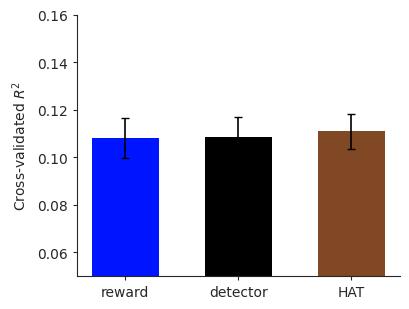

Figure saved to ./results/savefig/r2_barplot.png


In [47]:
# ───────────────────────────────────────────────
# Cross-validated R² per model WITH category fixed effects
# - Standardizes predictors in-fold (Pipeline)
# - One-hot encodes category (fixed effects)
# ───────────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

predictors = ['IOR_mean', 'IOR_backN_slope']  # add more if you want: 'IOR_std','IOR_step_slope','IOR_nextcurr_slope'

def prepare_group(g, y_col='nfix', x_cols=None):
    g = g.copy()
    # coerce numerics, drop inf/nan
    for c in (x_cols + [y_col]):
        g[c] = pd.to_numeric(g[c], errors='coerce')
    g[x_cols] = g[x_cols].replace([np.inf, -np.inf], np.nan)
    g[y_col]  = g[y_col].replace([np.inf, -np.inf], np.nan)
    g = g.dropna(subset=x_cols + [y_col] + ['category'])
    # ensure category is string (stable one-hot)
    g['category'] = g['category'].astype(str)
    return g

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results_r2_cat = []

for mname, g in featdf.groupby('model'):
    g = prepare_group(g, y_col='nfix', x_cols=predictors)

    if len(g) < 10 or g['nfix'].nunique() < 2:
        results_r2_cat.append({'model': mname, 'mean_R2': np.nan, 'std_R2': np.nan, 'n_images': len(g)})
        print(f"[{mname}] skipped (too few samples or no y variance). n={len(g)}")
        continue

    # In-fold preprocessing: z-score numeric predictors, one-hot category
    pre = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(with_mean=True, with_std=True), predictors),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop=None), ['category']),
        ],
        remainder='drop'
    )
    pipe = Pipeline([('pre', pre), ('lin', LinearRegression())])

    # X includes predictors + category, y is nfix
    X = g[predictors + ['category']]
    y = g['nfix'].values

    try:
        scores = cross_val_score(pipe, X, y, cv=kf, scoring='r2', error_score='raise')
        results_r2_cat.append({
            'model': mname,
            'mean_R2': float(np.mean(scores)),
            'std_R2': float(np.std(scores)),
            'n_images': len(g),
        })
        # print(f"[{mname}] CV R² (with category FE): {np.mean(scores):.3f} ± {np.std(scores):.3f}  (n={len(g)})")
    except Exception as e:
        # print(f"[{mname}] CV failed:", repr(e))
        results_r2_cat.append({'model': mname, 'mean_R2': np.nan, 'std_R2': np.nan, 'n_images': len(g)})

results_r2_cat = pd.DataFrame(results_r2_cat)
print("\n=== Cross-validated R² per model (with category FE) ===")
print(results_r2_cat)

# (Optional) quick bar plot
import numpy as np
import matplotlib.pyplot as plt

# Desired model order
order = [m for m in ['ours', 'detector', 'hat'] if m in results_r2_cat['model'].unique()]

# Color & label maps
color_map = {
    'ours':   "#0015FF",
    'detector': "#000000",
    'hat':    "#814825",
}
label_map = {
    'ours': "reward",
    'detector': "detector",
    'hat': "HAT",
}

g = results_r2_cat.set_index('model').loc[order]
means = g['mean_R2'].to_numpy()

# Compute SE instead of SD
n_folds = 5  # you used KFold(n_splits=5)
ses = g['std_R2'].to_numpy() / np.sqrt(n_folds)

x = np.arange(len(order))

fig, ax = plt.subplots(figsize=(4.2, 3.2))
bars = ax.bar(
    x, means, width=0.6,
    color=[color_map[m] for m in order],
    edgecolor='none'
)

ax.errorbar(
    x, means, yerr=ses,
    fmt='none', capsize=3, elinewidth=1.2, ecolor='k'
)

# Axis styling
ax.set_xticks(x, [label_map[m] for m in order])
ax.set_ylabel('Cross-validated $R^2$', labelpad=6)
# ax.set_ylabel('Cross-validated $R^2$ (mean ± s.e.)', labelpad=6)
ax.set_ylim(0.05, 0.16)

# Remove spines and background grid
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Clean ticks
ax.tick_params(axis='both', which='both', length=3, width=0.8)

# ax.set_title('Predicting nfix from IOR features (+ category fixed effects)', pad=8)
fig.tight_layout()
outpath = "./results/savefig/r2_barplot.png"
fig.savefig(outpath, dpi=300, bbox_inches='tight')

plt.show()
print(f"Figure saved to {outpath}")

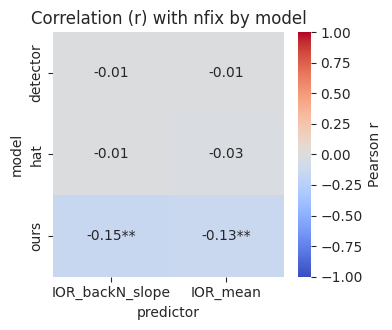

In [41]:
# ───────────────────────────────────────────────
# Correlation heatmap: predictors ↔ nfix, per model
# ───────────────────────────────────────────────
import numpy as np, pandas as pd
import seaborn as sns, matplotlib.pyplot as plt
from scipy import stats

# choose predictors to visualize
predictors = ['IOR_mean', 'IOR_backN_slope']  # add more if you have them: 'IOR_std','IOR_step_slope','IOR_nextcurr_slope'

rows = []
for mname, g in featdf.groupby('model'):
    # clean subset
    G = g.copy()
    for c in predictors + ['nfix']:
        G[c] = pd.to_numeric(G[c], errors='coerce')
    G = G.replace([np.inf, -np.inf], np.nan).dropna(subset=predictors + ['nfix'])

    for p in predictors:
        if G[p].nunique() < 2 or G['nfix'].nunique() < 2:
            r, pval = np.nan, np.nan
        else:
            r, pval = stats.pearsonr(G[p], G['nfix'])
        rows.append({'model': mname, 'predictor': p, 'r': r, 'p': pval})

corrdf = pd.DataFrame(rows)

# Build r-matrix for heatmap (models × predictors)
rmat = corrdf.pivot(index='model', columns='predictor', values='r')

# Make an annotation matrix with stars
def star(p):
    if pd.isna(p): return ''
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    if p < 0.10: return '†'
    return ''

ann = corrdf.copy()
ann['annot'] = corrdf['r'].round(2).astype(str) + corrdf['p'].map(star)
annmat = ann.pivot(index='model', columns='predictor', values='annot')

plt.figure(figsize=(1.6+1.2*len(predictors), 1.6+0.6*len(rmat)))
sns.heatmap(rmat, annot=annmat, fmt='', cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={'label':'Pearson r'})
plt.title('Correlation (r) with nfix by model')
plt.ylabel('model')
plt.xlabel('predictor')
plt.tight_layout()
plt.show()


# Archived: nfix prediction
- R2 is too low, across categories prediction may be too hard

In [ ]:
env = env_train
model = agent


if hparams.Data.TAP == 'TP':
    dataloader = train_img_loader # train_img_loader for using training image
    pa= hparams_tp.Data
#     pa['enforce_IOR'] = False
#     print(pa)
if hparams.Data.TAP == 'TA':
    dataloader =  train_img_loader
    pa= hparams_ta.Data
#     pa['enforce_IOR'] = False

model.eval()


scanpaths_train, visualizations_train = sample_scanpaths(env, model, dataloader, pa,
                                             sample_action=False, 
                                             sample_scheme='Greedy', # this is not necessary
                                             sample_stop=False,
                                             save_visualization=True,
                                             save_qonly=True)


In [ ]:
# code modified from evalaute in evaluation.py
env = env_valid
model = agent

    
if hparams.Data.TAP == 'TP':
    dataloader = valid_img_loader # train_img_loader for using training image
    pa= hparams_tp.Data
#     pa['enforce_IOR'] = False
#     print(pa)
if hparams.Data.TAP == 'TA':
    dataloader =  valid_img_loader_ta
    pa= hparams_ta.Data
#     pa['enforce_IOR'] = False

model.eval()


scanpaths_test, visualizations_test = sample_scanpaths(env, model, dataloader, pa,
                                             sample_action=False, 
                                             sample_scheme='Greedy', # this is not necessary
                                             sample_stop=False,
                                             save_visualization=True,
                                             save_qonly=True)

In [ ]:
# TODO: remove use_list and use_softmax parameters, they are not used anymore
def softmaxmap(m, alpha=1.0):
    orig_shape = m.shape
    m_tensor = torch.from_numpy(m).double().flatten()  # Preserve dtype
    m_tensor = m_tensor / alpha
    m_tensor = m_tensor - m_tensor.max()  # For numerical stability
    m_tensor = F.softmax(m_tensor, dim=0)
    m_softmax = np.reshape(m_tensor.numpy(), orig_shape)
    return m_softmax

def build_nfixdataset(visualizations_list, split, TAP, dataset_root, use_list=False, use_softmax=False):
    map_idx= 0 # map index to use 
    zoom_factors = (20 / 320, 32 / 512) # to reduce the size of the map

    # load human scanpaths
    human_scanpaths = load_human_scanpaths(split, TAP, dataset_root)
    print('total scanpaths under this TAP:', len(human_scanpaths))

    # load baselines
    if split =='train':
        baseline_pred = np.load(f'./baselines/Foveated Detector/pred_{TAP}_detection_hilow_aug_IOR_nfixtrain.npy', allow_pickle=True)
    else:
        baseline_pred = np.load(f'./baselines/Foveated Detector/pred_{TAP}_detection_hilow_aug.npy', allow_pickle=True)

    # get dataset
    data_nfixs =[]
    data_qmaps = []
    data_dmaps = []
    data_tasks, data_imgnames = [], []
    map_idx= 0 # map index to use for training

    for vis in tqdm(visualizations_list):
        task = vis[0]
        imgname = vis[1]
        data_tasks.append(task)
        data_imgnames.append(imgname)
        pair = task + "_" + imgname
        img_scanpaths = list(filter(lambda x: x['task'] +"_"+ x['name'] == pair, human_scanpaths))
        nfix = np.mean([sp['length'] for sp in img_scanpaths])
        assert nfix > 0, f"nfix is zero for {task} - {imgname}, check the scanpaths"
        data_nfixs.append(nfix)

        if use_list:
            qmaplist= []
            for idx in range(3):
                qmap = vis[2][map_idx+idx]
                if qmap.shape != (20, 32):
                    qmap = zoom(qmap, zoom_factors, order=1)
                qmap = softmaxmap(qmap) if use_softmax else qmap
                qmaplist.extend(list(qmap.flatten()))
            data_qmaps.append(np.array(qmaplist))
        else:
            qmap = vis[2][map_idx]
            if qmap.shape != (20, 32):
                qmap = zoom(qmap, zoom_factors, order=1)
            qmap = softmaxmap(qmap) if use_softmax else qmap
            data_qmaps.append(qmap.flatten())

        dmaps = [pred['attn_map'] for pred in baseline_pred if pred['task'] == task and pred['name'] == imgname]
        assert len(dmaps) == 1, f"Expected one prediction for {task} - {imgname}, got {len(dmaps)}"

        if use_list:
            dmaplist= []
            for idx in range(3):
                dmap = dmaps[0][map_idx+1+idx]  # always full size, always zoom
                dmap = zoom(dmap, zoom_factors, order=1)
                dmap = softmaxmap(dmap) if use_softmax else dmap
                dmaplist.extend(list(dmap.flatten()))
            data_dmaps.append(np.array(dmaplist))
        else:
            dmap = dmaps[0][map_idx+1]
            dmap = zoom(dmap, zoom_factors, order=1)  
            dmap = softmaxmap(dmap) if use_softmax else dmap
            data_dmaps.append(dmap.flatten())
    return data_nfixs, data_qmaps, data_dmaps, data_tasks, data_imgnames

train_nfixs, train_qmaps, train_dmaps, train_tasks, train_imgnames = \
    build_nfixdataset(visualizations_train, 'train', TAP, dataset_root, use_list=False, use_softmax=False)

test_nfixs, test_qmaps, test_dmaps, test_tasks, test_imgnames = \
    build_nfixdataset(visualizations_test, 'test', TAP, dataset_root, use_list=False, use_softmax=False)


# print("qmap shape:", np.array(train_qmaps).shape)
# print("dmap shape:", np.array(train_dmaps).shape)
# print("qmap sum:", np.array(train_qmaps)[0].sum())
# print("dmap sum:", np.array(train_dmaps)[0].sum())
# plt.imshow(np.array(train_qmaps)[0].reshape(20, 32), cmap='hot')
# plt.show()
# plt.imshow(np.array(train_dmaps)[0].reshape(20, 32), cmap='hot')
# plt.show()



In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


save_fig = True
# --- model training function ---
def train_map_to_nfix(train_maps, train_nfixs, alpha=1.0, label=""):
    X = np.asarray(train_maps, dtype=np.float32)
    y = np.asarray(train_nfixs, dtype=np.float32).ravel()

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    model = make_pipeline(
        StandardScaler(with_mean=False),
        Ridge(alpha=alpha, fit_intercept=True, random_state=42)
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    print(f"[{label} alpha={alpha}]  MSE = {mse:.3f}   R² = {r2:.3f}")
    return model

# --- training ---
print("Reward model training:")
reward_model = train_map_to_nfix(train_qmaps, train_nfixs, alpha=1.0, label='Reward')

print("Target model training:")
target_model = train_map_to_nfix(train_dmaps, train_nfixs, alpha=1.0, label='Target')

# --- testing ---
X_reward = np.array(test_qmaps)
X_target = np.array(test_dmaps)
y_test = np.array(test_nfixs).ravel()

reward_pred = reward_model.predict(X_reward)
target_pred = target_model.predict(X_target)

# --- results dataframe ---
df = pd.DataFrame({
    'task': test_tasks,
    'actual_nfix': y_test,
    'reward_nfix': reward_pred,
    'target_nfix': target_pred
})

# --- per-task metrics ---
def task_metrics(subdf):
    y_true = subdf['actual_nfix']
    return pd.Series({
        'n_trials'     : len(subdf),
        'actual_mean'  : y_true.mean(),
        'reward_mean'  : subdf['reward_nfix'].mean(),
        'target_mean'  : subdf['target_nfix'].mean(),
        'reward_MSE'   : mean_squared_error(y_true, subdf['reward_nfix']),
        'reward_R2'    : r2_score(y_true, subdf['reward_nfix']),
        'target_MSE'   : mean_squared_error(y_true, subdf['target_nfix']),
        'target_R2'    : r2_score(y_true, subdf['target_nfix']),
    })

metrics_by_task = df.groupby('task').apply(task_metrics).reset_index()

metrics_by_task = metrics_by_task.sort_values(by='actual_mean').reset_index(drop=True)

print(metrics_by_task)

# --- line plot: average nfix ---
fig, ax = plt.subplots(figsize=(10, 3))
x = np.arange(len(metrics_by_task))

# Apply small jitter offsets
jitter = 0.05
x_human  = x 
x_reward = x - jitter
x_target = x + jitter

# Plot with jittered x-positions
ax.plot(x_human, metrics_by_task['actual_mean'], marker='o', linestyle='-',
        label='human', color='white', markeredgecolor='black', linewidth=1.5)
# ax.plot(x_human, metrics_by_task['actual_mean'], linestyle='-', color='black',
#         label='Human', linewidth=1.5)
# ax.scatter(x_human, metrics_by_task['actual_mean'], marker='o',
#            facecolor='white', edgecolor='black', s=50, zorder=3)
ax.plot(x_reward, metrics_by_task['reward_mean'], marker='o', linestyle='-',
        label='reward', color='blue', linewidth=2)
ax.plot(x_target, metrics_by_task['target_mean'], marker='o', linestyle='-',
        label='target', color='gray', linewidth=2)

# Styling
ax.set_xticks(x)
ax.set_xticklabels(metrics_by_task['task'], rotation=45, ha='right')
ax.set_ylabel('average num of fix')
# ax.set_title('Actual vs. Predicted Mean n-fix per Task')
ax.set_ylim(3, 8)
ax.legend(loc='lower right', frameon=False)
ax.grid(True, linestyle='--', alpha=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

if save_fig:
    plt.savefig('results/savefig/nfix_model_comparison.png', dpi=300, bbox_inches='tight')

plt.show()


# --- bar plot: average nfix ---
# fig, ax = plt.subplots(figsize=(10, 3))

# bar_width = 0.25
# x = np.arange(len(metrics_by_task))

# ax.bar(x - bar_width, metrics_by_task['actual_mean'], width=bar_width,
#        label='Human', color='white', edgecolor='black')
# ax.bar(x, metrics_by_task['reward_mean'], width=bar_width,
#        label='Reward', color='blue')
# ax.bar(x + bar_width, metrics_by_task['target_mean'], width=bar_width,
#        label='Target', color='gray')

# ax.set_xticks(x)
# ax.set_xticklabels(metrics_by_task['task'], rotation=45, ha='right')
# ax.set_ylabel('Mean n-fix')
# ax.set_title('Actual vs. Predicted Mean n-fix per Task')
# ax.legend()
# plt.ylim(3,8)
# plt.tight_layout()
# plt.show()

# --- bar plot: R² per task ---
fig, ax = plt.subplots(figsize=(10, 3))
x = np.arange(len(metrics_by_task))
ax.bar(x - 0.15, metrics_by_task['reward_R2'], width=0.3, label='Reward R²', color='blue')
ax.bar(x + 0.15, metrics_by_task['target_R2'], width=0.3, label='Target R²', color='gray')

ax.set_xticks(x)
ax.set_xticklabels(metrics_by_task['task'], rotation=45, ha='right')
ax.set_ylabel('R² Score')
ax.set_title('Model Fit per Task (Higher is Better)')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.utils import resample
from scipy.stats import ttest_rel

# ----------------------------------------------------------------------
# 1.  Paired bootstrap of any metric
# ----------------------------------------------------------------------
def paired_bootstrap_metric(y, a, b, metric_fn, n_boot=1000, seed=0):
    """Return mean diff (A–B), 95 % CI and bootstrap p‑value (two‑tailed)."""
    rng   = np.random.RandomState(seed)
    n     = len(y)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        idx        = rng.randint(0, n, n)          # paired resample
        diffs[i]   = metric_fn(y[idx], a[idx]) - metric_fn(y[idx], b[idx])
    ci = np.percentile(diffs, [2.5, 97.5])
    p  = (np.mean(diffs <= 0) if diffs.mean() > 0 else np.mean(diffs >= 0)) * 2
    return diffs.mean(), ci[0], ci[1], p

# ----------------------------------------------------------------------
# 2.  Wrapper that also does a paired t‑test on per‑trial squared‑error
# ----------------------------------------------------------------------
def metric_comparison(y, a, b, n_boot=1000, seed=0):
    # bootstrap Δ R² (Reward – Target)
    d_r2, lo_r2, hi_r2, p_r2 = paired_bootstrap_metric(
        y, a, b, r2_score, n_boot, seed)

    # bootstrap Δ MSE (Target – Reward)  – note the sign!
    d_mse, lo_mse, hi_mse, p_mse = paired_bootstrap_metric(
        y, b, a, mean_squared_error, n_boot, seed)

    # classic paired t‑test on trial‑level SEs
    se_reward = (y - a)**2
    se_target = (y - b)**2
    t_stat, p_t = ttest_rel(se_target, se_reward)

    return pd.Series({
        'ΔR2'      : d_r2,   'R2_CI_low' : lo_r2,  'R2_CI_high' : hi_r2,  'R2_p' : p_r2,
        'ΔMSE'     : d_mse,  'MSE_CI_low': lo_mse, 'MSE_CI_high': hi_mse, 'MSE_p': p_mse,
        't_stat'   : t_stat, 't_p'       : p_t
    })

# ----------------------------------------------------------------------
# 3.  Overall comparison
# ----------------------------------------------------------------------
overall_stats = metric_comparison(df['actual_nfix'].values,
                                  df['reward_nfix'].values,
                                  df['target_nfix'].values)

print("\n=== Overall significance test ===")
print(overall_stats.to_string(float_format='%.3g'))

# ----------------------------------------------------------------------
# 4.  Category‑wise comparison
# ----------------------------------------------------------------------
task_stats = (df.groupby('task')
                .apply(lambda g: metric_comparison(g['actual_nfix'].values,
                                                   g['reward_nfix'].values,
                                                   g['target_nfix'].values))
                .reset_index())

print("\n=== Per‑task significance tests ===")
print(task_stats.to_string(index=False, float_format='%.3g'))

# Select only MSE-related columns
mse_columns = ['task', 'ΔMSE', 'MSE_CI_low', 'MSE_CI_high', 'MSE_p']
mse_table = task_stats[mse_columns]

# Convert to LaTeX tabular format
latex_table = mse_table.to_latex(index=False,
                                  float_format="%.3f",
                                  column_format="lrrrr",
                                  header=['Task', r'$\Delta$MSE', 'CI Low', 'CI High', 'p-value'])


# Save to text file
with open("results/savefig/mse_table.txt", "w") as f:
    f.write(latex_table)

# Archive

In [ ]:


# font = ImageFont.truetype("../Gidole/Resources/GidoleFont/Gidole-Regular.ttf", size=32)
font = ImageFont.truetype("Gidole-Regular.ttf", size=32)

for i in range(0, 15):#len(batch['is_last'])):
    if not batch['is_last'][i]:
        if hparams.Data.name == 'OSIE':
            img = Image.open(join(dataset_root, 'OSIE/images/{}'.format(batch['img_name'][i])))
        else:
            img = Image.open(join(dataset_root, 'images/{}/{}'.format(batch['task_name'][i].replace(' ', '_'), batch['img_name'][i])))
        if img.size[0] != hparams.Data.im_w:
            img = img.resize((hparams.Data.im_w, hparams.Data.im_h))
        img_ori = copy.deepcopy(img)
        fixs = batch['next_normalized_fixations'][i][
            (1-batch['is_padding'][i]).bool()].numpy() * np.array([hparams.Data.im_w, hparams.Data.im_h]).astype(np.int32)

        for k in range(len(fixs)):
            ImageDraw.Draw(
                img  # Image
            ).text(
                list(fixs[k]),  # Coordinates
                str(k),  # Text
                (255, 255, 0),  # Color
                font=font,
                stroke_width=1,
            )
        next_fix = (batch['next_normalized_fixations'][i][-1].numpy() * np.array(
            [hparams.Data.im_w, hparams.Data.im_h])).astype(np.int32)
        ImageDraw.Draw(img).text(
            list(next_fix),  # Coordinates
            str(k + 1),  # Text
            (255, 0, 0),  # Color
            font=font,
            stroke_width=1,
        )
        plt.figure(figsize=(20, 10))
        plt.subplot(131)
        plt.title(batch['task_name'][i])
        plt.imshow(img)

        plt.subplot(132)
        hm = probs[i]
        hm /= hm.max()
        hm = ((1 - hm) * 255).astype(np.uint8)
        hm = cv2.applyColorMap(hm, cv2.COLORMAP_JET)
        plt.imshow(cv2.addWeighted(hm, 0.5, np.array(img_ori), 0.5, 0))
        # plt.imshow(probs[i])

        plt.subplot(133)
        # plt.imshow(img_ori)
        # plt.imshow(cids[i], alpha=0.5)
        plt.imshow(target_fix_maps[i])

In [ ]:


# hparams_tp.Data,
# bbox_annos,
# human_cdf,
# fix_clusters,
# prior_maps_tp,
# sss_strings,
# dataset_root,
# sps_test_tp,

# log_dir=log_dir,
# save_visualization=save_visualization,

In [ ]:


# generating scanpaths
env.max_step = pa.max_traj_length + 1
all_actions, all_rewards = [], []
print('Generating scanapths...')
for subj_id in range(10):
    for batch in tqdm(dataloader):
        env.set_data(batch)
        img_names_batch = batch['img_name']
        cat_names_batch = batch['cat_name']
        cond_batch = batch['condition']
        with torch.no_grad():
            env.reset()
            trajs = collect_trajs(
                env,
                model,
                pa.patch_num,
                pa.max_traj_length,
                is_eval=True,
                sample_action=sample_action,
                sample_scheme=sample_scheme,
                sample_stop=sample_stop,
                save_visualization=True,
            )
            all_actions.extend([(cat_names_batch[i], img_names_batch[i],
                                 cond_batch[i], trajs[i]['actions'])
                                for i in range(env.batch_size)])


            for i in range(env.batch_size):
                qs = F.interpolate(
                    trajs[i]['q_values'].view(-1, 1, 20, 32),
                    size=(pa.im_h, pa.im_w),
                    mode='bilinear').squeeze(1).cpu().numpy().astype(np.float16)
                rs = F.interpolate(
                    trajs[i]['rewards'].view(-1, 1, 20, 32),
                    size=(pa.im_h, pa.im_w),
                    mode='bilinear').squeeze(1).cpu().numpy().astype(np.float16)
                ps = F.interpolate(
                    trajs[i]['probs'].view(-1, 1, 20, 32),
                    size=(pa.im_h, pa.im_w),
                    mode='bilinear').squeeze(1).cpu().numpy().astype(np.float16)
                all_rewards.append((cat_names_batch[i],
                                    img_names_batch[i], qs, rs, ps))

    if not sample_action:
        break
        
scanpaths = utils.actions2scanpaths(all_actions, pa.patch_num)

In [ ]:
scanpaths, visualizations = sample_scanpaths(env, model, dataloader, pa,
                                             sample_action, sample_scheme,
                                             sample_stop,
                                             save_visualization)
nonstop_scanpaths = deepcopy(scanpaths)